# Values considered "missing"

In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.Series([1, 2], dtype=np.int64).reindex([0, 1, 2])

0    1.0
1    2.0
2    NaN
dtype: float64

In [3]:
pd.Series([True, False], dtype=np.bool_).reindex([0, 1, 2])

0     True
1    False
2      NaN
dtype: object

In [4]:
pd.Series([1, 2], dtype=np.dtype("timedelta64[ns]")).reindex([0, 1, 2])

0   0 days 00:00:00.000000001
1   0 days 00:00:00.000000002
2                         NaT
dtype: timedelta64[ns]

In [5]:
pd.Series([1, 2], dtype=np.dtype("datetime64[ns]")).reindex([0, 1, 2])

0   1970-01-01 00:00:00.000000001
1   1970-01-01 00:00:00.000000002
2                             NaT
dtype: datetime64[ns]

In [6]:
pd.Series(["2020", "2020"], dtype=pd.PeriodDtype("D")).reindex([0, 1, 2])

0    2020-01-01
1    2020-01-01
2           NaT
dtype: period[D]

In [7]:
pd.Series([1, 2], dtype="Int64").reindex([0, 1, 2])

0       1
1       2
2    <NA>
dtype: Int64

In [9]:
ser = pd.Series([pd.Timestamp("2020-01-01"), pd.NaT])
ser

0   2020-01-01
1          NaT
dtype: datetime64[ns]

In [10]:
pd.isna(ser)

0    False
1     True
dtype: bool

In [11]:
ser = pd.Series([1, None], dtype=object)
ser

0       1
1    None
dtype: object

In [12]:
pd.isna(ser)

0    False
1     True
dtype: bool

In [13]:
None == None

True

In [15]:
# But np.nan, pd.NaT and pd.NA do not compare
print(np.nan == np.nan)
print(pd.NaT == pd.NaT)
print(pd.NA == pd.NA)

False
False
<NA>


## `NA` Semantics

In [16]:
s = pd.Series([1, 2, None], dtype="Int64")
s

0       1
1       2
2    <NA>
dtype: Int64

In [17]:
s[2]

<NA>

In [18]:
s[2] is pd.NA

True

## Propagation in Arithmetic and Comparison Operations

In [19]:
# If one of the operands is unknown, the outcome of the operation is also unknown.
pd.NA + 1

<NA>

In [20]:
"a" * pd.NA

<NA>

In [21]:
# ...with a few exceptions
pd.NA**0

1

In [22]:
1**pd.NA

1

In [23]:
pd.NA == 1

<NA>

In [24]:
pd.NA == pd.NA

<NA>

In [25]:
pd.NA < 2.5

<NA>

In [26]:
pd.isna(pd.NA)

True

## Logical Operations

In [27]:
True | False

True

In [28]:
True | pd.NA

True

In [29]:
False | pd.NA

<NA>

In [30]:
False & pd.NA

False

## `NA` in a boolean context

In [31]:
# The following is ambiguous
bool(pd.NA)

TypeError: boolean value of NA is ambiguous

## NumPy ufuncs

In [32]:
np.log(pd.NA)

<NA>

In [33]:
np.add(pd.NA, 1)

<NA>

## Conversion

In [35]:
import io

data = io.StringIO("a,b\n,True\n2,")
df = pd.read_csv(data)
df

,a,b
0,NaN,True
1,2.0,NaN


In [36]:
df.dtypes

a    float64
b     object
dtype: object

In [37]:
df_conv = df.convert_dtypes()
df_conv

,a,b
0,<NA>,True
1,2,<NA>


In [38]:
df_conv.dtypes

a      Int64
b    boolean
dtype: object

# Inserting Missing Data

In [39]:
ser = pd.Series([1.0, 2.0, 3.0])
ser.loc[0] = None
ser
# Inserting a missing value in place of a float -> NaN

0    NaN
1    2.0
2    3.0
dtype: float64

In [40]:
ser = pd.Series([pd.Timestamp("2021"), pd.Timestamp("2021")])
ser.iloc[0] = np.nan
ser
# Inserting a missing value in place of a Timestamp -> NaT

0          NaT
1   2021-01-01
dtype: datetime64[ns]

In [43]:
ser = pd.Series([True, False], dtype=np.bool_)
ser.iloc[0] = None
ser

C:\Users\nkmil\AppData\Local\Temp\ipykernel_16688\4054551022.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ser.iloc[0] = None


0      NaN
1    False
dtype: object

In [44]:
s = pd.Series(["a", "b", "c"], dtype=object)
s.loc[0] = None
s.loc[1] = np.nan
s

0    None
1     NaN
2       c
dtype: object

# Calculations with missing data

In [45]:
ser1 = pd.Series([np.nan, np.nan, 2, 3])
ser2 = pd.Series([np.nan, 1, np.nan, 4])

ser1 + ser2

0    NaN
1    NaN
2    NaN
3    7.0
dtype: float64

In [46]:
# When summing data, NA values are treated as zero
pd.Series([np.nan]).sum()

np.float64(0.0)

In [47]:
# When taking the product, NA values are treated as one.
pd.Series([np.nan]).prod()

np.float64(1.0)

In [48]:
# Cumulative methods by default ignore missing values
ser = pd.Series([1, np.nan, 3, np.nan])
ser

0    1.0
1    NaN
2    3.0
3    NaN
dtype: float64

In [49]:
ser.cumsum()

0    1.0
1    NaN
2    4.0
3    NaN
dtype: float64

# Dropping missing data

In [50]:
df = pd.DataFrame([[np.nan, 1, 2], [1, 2, np.nan], [1, 2, 3]])
df

,0,1,2
0,NaN,1,2.0
1,1.0,2,NaN
2,1.0,2,3.0


In [51]:
df.dropna()

,0,1,2
2,1.0,2,3.0


In [52]:
df.dropna(axis=1)

,1
0,1
1,2
2,2


# Filling Missing Data
## Filling by value

In [55]:
data = {
    "np": [1.0, np.nan, np.nan, 2],
    "arrow": pd.array([1.0, pd.NA, pd.NA, 2], dtype="Float64"),
}
df = pd.DataFrame(data)
df

,np,arrow
0,1.0,1.0
1,NaN,<NA>
2,NaN,<NA>
3,2.0,2.0


In [56]:
df.ffill()

,np,arrow
0,1.0,1.0
1,1.0,1.0
2,1.0,1.0
3,2.0,2.0


In [57]:
df.bfill()

,np,arrow
0,1.0,1.0
1,2.0,2.0
2,2.0,2.0
3,2.0,2.0


In [59]:
# Use corresponding values from another df to fill missing values
dff = pd.DataFrame(
    np.arange(30, dtype=np.float64).reshape(10, 3),
    columns=list("ABC"),
)
dff.iloc[3:5, 0] = np.nan
dff.iloc[4:6, 1] = np.nan
dff.iloc[5:8, 2] = np.nan

dff

,A,B,C
0,0.0,1.0,2.0
1,3.0,4.0,5.0
2,6.0,7.0,8.0
3,NaN,10.0,11.0
4,NaN,NaN,14.0
5,15.0,NaN,NaN
6,18.0,19.0,NaN
7,21.0,22.0,NaN
8,24.0,25.0,26.0
9,27.0,28.0,29.0


In [60]:
dff.fillna(dff.mean())

,A,B,C
0,0.00,1.0,2.000000
1,3.00,4.0,5.000000
2,6.00,7.0,8.000000
3,14.25,10.0,11.000000
4,14.25,14.5,14.000000
5,15.00,14.5,13.571429
6,18.00,19.0,13.571429
7,21.00,22.0,13.571429
8,24.00,25.0,26.000000
9,27.00,28.0,29.000000


In [62]:
dff.where(pd.notna(dff), dff.mean(), axis="columns")

,A,B,C
0,0.00,1.0,2.000000
1,3.00,4.0,5.000000
2,6.00,7.0,8.000000
3,14.25,10.0,11.000000
4,14.25,14.5,14.000000
5,15.00,14.5,13.571429
6,18.00,19.0,13.571429
7,21.00,22.0,13.571429
8,24.00,25.0,26.000000
9,27.00,28.0,29.000000


## Interpolation

In [63]:
df = pd.DataFrame(
    {
        "A": [1, 2.1, np.nan, 4.7, 5.6, 6.8],
        "B": [0.25, np.nan, np.nan, 4, 12.2, 14.4],
    }
)
df

,A,B
0,1.0,0.25
1,2.1,NaN
2,NaN,NaN
3,4.7,4.00
4,5.6,12.20
5,6.8,14.40


In [64]:
df.interpolate()

,A,B
0,1.0,0.25
1,2.1,1.50
2,3.4,2.75
3,4.7,4.00
4,5.6,12.20
5,6.8,14.40


In [66]:
idx = pd.date_range("2020-01-01", periods=10, freq="D")
data = np.random.default_rng(2).integers(0, 10, 10).astype(np.float64)
ts = pd.Series(data, index=idx)
ts.iloc[[1, 2, 5, 6, 9]] = np.nan

ts

2020-01-01    8.0
2020-01-02    NaN
2020-01-03    NaN
2020-01-04    2.0
2020-01-05    4.0
2020-01-06    NaN
2020-01-07    NaN
2020-01-08    0.0
2020-01-09    3.0
2020-01-10    NaN
Freq: D, dtype: float64

<Axes: >

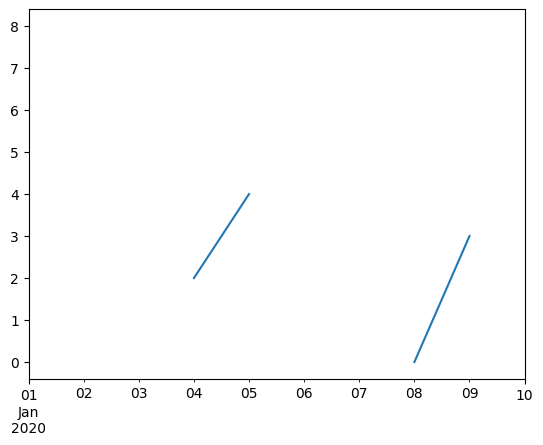

In [67]:
ts.plot()

In [68]:
ts.interpolate()

2020-01-01    8.000000
2020-01-02    6.000000
2020-01-03    4.000000
2020-01-04    2.000000
2020-01-05    4.000000
2020-01-06    2.666667
2020-01-07    1.333333
2020-01-08    0.000000
2020-01-09    3.000000
2020-01-10    3.000000
Freq: D, dtype: float64

<Axes: >

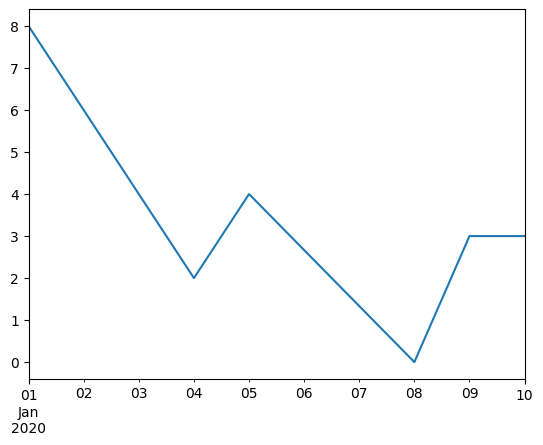

In [69]:
ts.interpolate().plot()

In [70]:
ts2 = ts.iloc[[0, 1, 3, 7, 9]]
ts2.interpolate()

2020-01-01    8.0
2020-01-02    5.0
2020-01-04    2.0
2020-01-08    0.0
2020-01-10    0.0
dtype: float64

In [71]:
ts2.interpolate(method="time")

2020-01-01    8.0
2020-01-02    6.0
2020-01-04    2.0
2020-01-08    0.0
2020-01-10    0.0
dtype: float64

In [72]:
idx = [0.0, 1.0, 10.0]
ser = pd.Series([0.0, np.nan, 10.0], idx)
ser

0.0      0.0
1.0      NaN
10.0    10.0
dtype: float64

In [73]:
ser.interpolate()

0.0      0.0
1.0      5.0
10.0    10.0
dtype: float64

In [74]:
ser.interpolate(method="values")

0.0      0.0
1.0      1.0
10.0    10.0
dtype: float64

In [75]:
df = pd.DataFrame(
    {
        "A": [1, 2.1, np.nan, 4.7, 5.6, 6.8],
        "B": [0.25, np.nan, np.nan, 4, 12.2, 14.4],
    }
)
df

,A,B
0,1.0,0.25
1,2.1,NaN
2,NaN,NaN
3,4.7,4.00
4,5.6,12.20
5,6.8,14.40


In [76]:
df.interpolate(method="barycentric")

,A,B
0,1.00,0.250
1,2.10,-7.660
2,3.53,-4.515
3,4.70,4.000
4,5.60,12.200
5,6.80,14.400


In [77]:
df.interpolate(method="pchip")

,A,B
0,1.00000,0.250000
1,2.10000,0.672808
2,3.43454,1.928950
3,4.70000,4.000000
4,5.60000,12.200000
5,6.80000,14.400000


In [78]:
df.interpolate(method="akima")

,A,B
0,1.000000,0.250000
1,2.100000,-0.873316
2,3.406667,0.320034
3,4.700000,4.000000
4,5.600000,12.200000
5,6.800000,14.400000


In [79]:
df.interpolate(method="spline", order=2)

,A,B
0,1.000000,0.250000
1,2.100000,-0.428598
2,3.404545,1.206900
3,4.700000,4.000000
4,5.600000,12.200000
5,6.800000,14.400000


<Axes: >

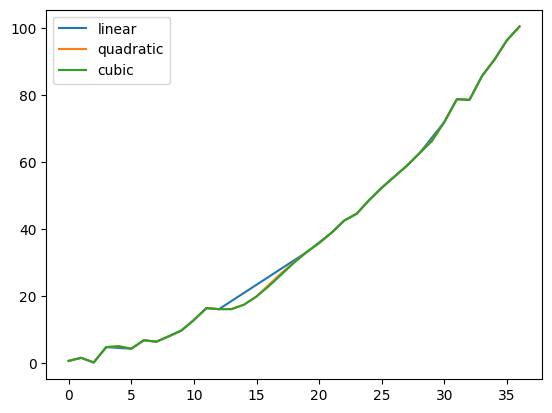

In [80]:
# Comparison of various interpolation methods
np.random.seed(2)
ser = pd.Series(np.arange(1, 10.1, 0.25) ** 2 + np.random.randn(37))
missing = np.array([4, 13, 14, 15, 16, 17, 18, 20, 29])
ser.iloc[missing] = np.nan
methods = ["linear", "quadratic", "cubic"]
df = pd.DataFrame({m: ser.interpolate(method=m) for m in methods})

df.plot()

### Interpolation Limits

In [81]:
# Limit number of consecutive NaN values filled
ser = pd.Series([np.nan, np.nan, 5, np.nan, np.nan, np.nan, 13, np.nan, np.nan])
ser

0     NaN
1     NaN
2     5.0
3     NaN
4     NaN
5     NaN
6    13.0
7     NaN
8     NaN
dtype: float64

In [82]:
ser.interpolate()

0     NaN
1     NaN
2     5.0
3     7.0
4     9.0
5    11.0
6    13.0
7    13.0
8    13.0
dtype: float64

In [83]:
ser.interpolate(limit=1)

0     NaN
1     NaN
2     5.0
3     7.0
4     NaN
5     NaN
6    13.0
7    13.0
8     NaN
dtype: float64

In [84]:
ser.interpolate(limit=1, limit_direction="backward")

0     NaN
1     5.0
2     5.0
3     NaN
4     NaN
5    11.0
6    13.0
7     NaN
8     NaN
dtype: float64

# Replacing Values

In [85]:
df = pd.DataFrame(np.eye(3))
df

,0,1,2
0,1.0,0.0,0.0
1,0.0,1.0,0.0
2,0.0,0.0,1.0


In [86]:
df_missing = df.replace(0, np.nan)
df_missing

,0,1,2
0,1.0,NaN,NaN
1,NaN,1.0,NaN
2,NaN,NaN,1.0


In [87]:
df_filled = df_missing.replace(np.nan, 2)
df_filled

,0,1,2
0,1.0,2.0,2.0
1,2.0,1.0,2.0
2,2.0,2.0,1.0


## Regular Expression Replacement

In [89]:
d = {
    "a": list(range(4)),
    "b": list("ab.."),
    "c": ["a", "b", np.nan, "d"],
}
df = pd.DataFrame(d)
df.replace(".", np.nan)

,a,b,c
0,0,a,a
1,1,b,b
2,2,NaN,NaN
3,3,NaN,d


In [90]:
df.replace(r"\s*\.\s*", np.nan, regex=True)

,a,b,c
0,0,a,a
1,1,b,b
2,2,NaN,NaN
3,3,NaN,d


In [91]:
df.replace([r"\.", r"(a)"], ["dot", r"\1stuff"], regex=True)

,a,b,c
0,0,astuff,astuff
1,1,b,b
2,2,dot,NaN
3,3,dot,d
